# k-means cluster analysis

The k-means algorithm is one of the most popular and straightforward techniques for Cluster Analysis. Here's how it works:

1. Choose `k`, the number of clusters.
2. Initialize `k` centroids randomly.
3. Assign each point to the nearest centroid (based on Euclidean distance).
4. Recalculate centroids as the mean of all points assigned to each cluster.
5. Repeat steps 3–4 until the centroids no longer move significantly (convergence).

A basic Python example using `scikit-learn` looks like:


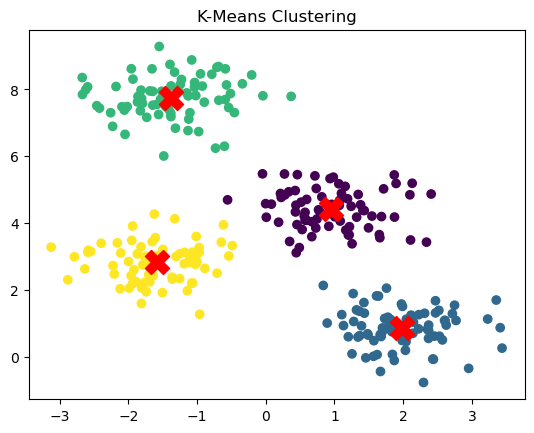

In [7]:
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import warnings
warnings.filterwarnings('ignore')

# Generate synthetic data
X, _ = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=0)

# Fit k-means
kmeans = KMeans(n_clusters=4, random_state=0)
kmeans.fit(X)

# Plot the results
plt.scatter(X[:, 0], X[:, 1], c=kmeans.labels_, cmap='viridis')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            s=300, c='red', marker='X')
plt.title("K-Means Clustering")
plt.show()


## Evaluating a cluster model

Since clustering is unsupervised, we often don't have external truth labels to directly evaluate against. Instead, we use internal metrics that assess compactness (how close the points in a cluster are) and separation (how far apart the clusters are).

Here are some metrics for the dataset above

### Inertia (Within-Cluster Sum of Squares – WCSS)

- Measures how tightly the samples are grouped within each cluster.
- Lower values are better, but decreasing inertia with more clusters is expected.
- Used in the elbow method.

In [8]:
print("Inertia:", kmeans.inertia_)

Inertia: 212.00599621083475


### Silhouette Score

- Combines cohesion and separation.
- Ranges from -1 to 1:
  - +1 means well-clustered
  - 0 indicates overlapping clusters
  - Negative values suggest incorrect clustering
- Useful for comparing different values of k.

In [9]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X, kmeans.labels_)
print("Silhouette Score:", score)


Silhouette Score: 0.6819938690643478


### Davies-Bouldin Index

- Measures the ratio of within-cluster distances to between-cluster distances.
- Lower values indicate better clustering

In [10]:
from sklearn.metrics import davies_bouldin_score

db_score = davies_bouldin_score(X, kmeans.labels_)
print("Davies-Bouldin Index:", db_score)

Davies-Bouldin Index: 0.43756400782378396


## Techniques for Choosing the Optimal Number of Clusters (k)

### Elbow Method

- Plot `k` vs. inertia.
- Look for the "elbow" point where adding more clusters doesn't significantly improve the result.

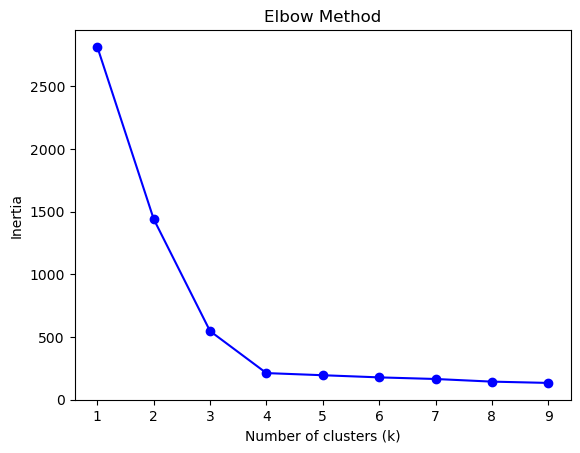

In [11]:
inertias = []
k_values = range(1, 10)

for k in k_values:
    model = KMeans(n_clusters=k, random_state=0)
    model.fit(X)
    inertias.append(model.inertia_)

plt.plot(k_values, inertias, 'bo-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()


### Silhouette Analysis

- Plot average silhouette score for different values of k.
- Choose the k with the highest score.

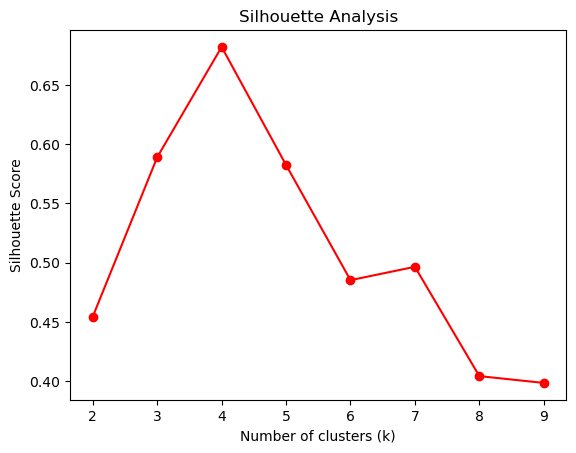

In [12]:
silhouette_scores = []

for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=0)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)

plt.plot(range(2, 10), silhouette_scores, 'ro-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Analysis')
plt.show()


### Example of multiple metrics

Here's a Python code snippet that runs K-Means clustering across a range of `k
` values, then evaluates and plots the following:

- Inertia (Elbow Method)
- Silhouette Score
- Davies-Bouldin Index

This gives you a side-by-side look at how different metrics behave as you vary `k`.

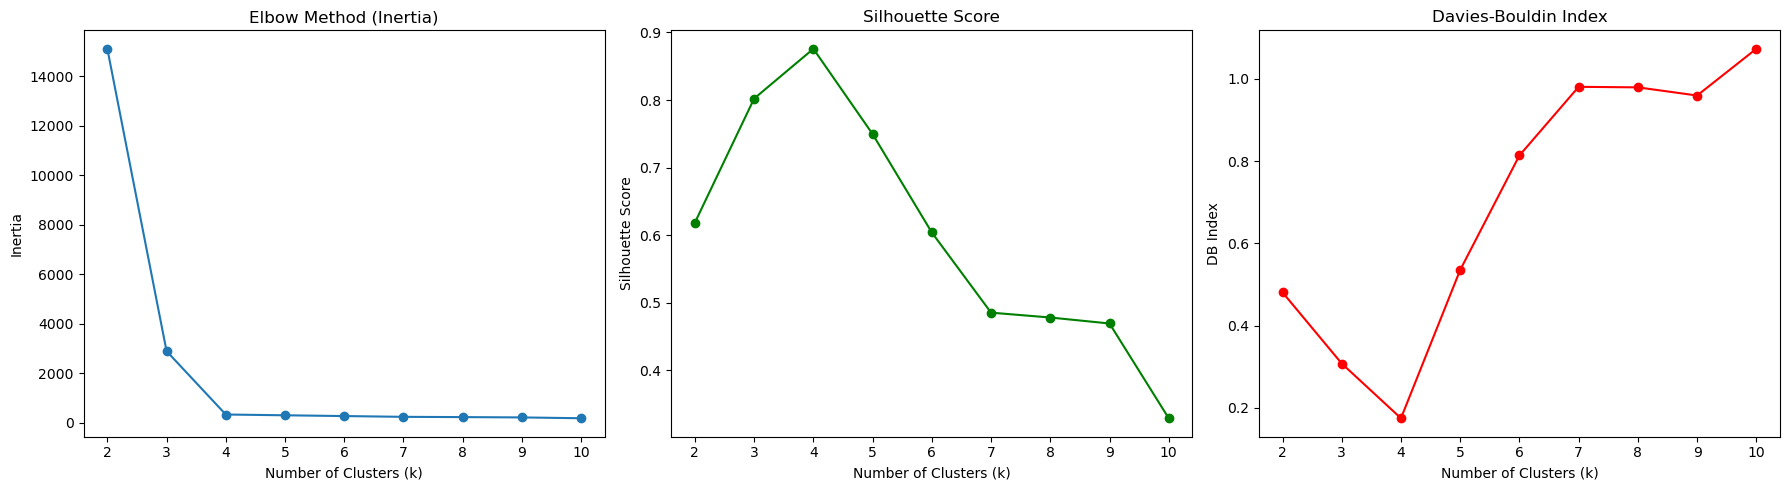

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Generate synthetic dataset
X, _ = make_blobs(n_samples=500, centers=4, cluster_std=0.6, random_state=42)

# Initialize lists for metrics
inertias = []
silhouette_scores = []
db_indices = []
k_range = range(2, 11)  # Try k from 2 to 10

# Evaluate clustering for each k
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)

    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X, labels))
    db_indices.append(davies_bouldin_score(X, labels))

# Plotting
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# Elbow Method
axs[0].plot(k_range, inertias, marker='o')
axs[0].set_title('Elbow Method (Inertia)')
axs[0].set_xlabel('Number of Clusters (k)')
axs[0].set_ylabel('Inertia')

# Silhouette Score
axs[1].plot(k_range, silhouette_scores, marker='o', color='green')
axs[1].set_title('Silhouette Score')
axs[1].set_xlabel('Number of Clusters (k)')
axs[1].set_ylabel('Silhouette Score')

# Davies-Bouldin Index
axs[2].plot(k_range, db_indices, marker='o', color='red')
axs[2].set_title('Davies-Bouldin Index')
axs[2].set_xlabel('Number of Clusters (k)')
axs[2].set_ylabel('DB Index')

plt.tight_layout()
plt.show()
